In [3]:
import os
import re
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append('..')
from utils.analysis import est_vifs

In [5]:
OUTPUTS_DIR = '/home/ubuntu/data/learning-habits/spm_format/outputs'

# Models to compare — add or remove entries as needed
MODELS = {
    'glm2_all_runs':         'glm2_all_runs_scrubbed_2025-12-11-12-44',
    'glm2_chosen_v1':        'glm2_chosen_all_runs_scrubbed_2025-12-11-11-22',
    'glm2_chosen_v2':        'glm2_chosen_all_runs_scrubbed_2026-03-17-02-53',
    'glm3_chosen_choice_var':'glm3_chosen_choice_var_scrubbed_2026-04-01-01-29',
}

In [7]:
def load_dms_allruns(model_dir):
    """Load design matrices from base_dir/sub-XX/sub-XX_design_matrix.csv."""
    subjects = sorted(d for d in os.listdir(model_dir) if d.startswith('sub-'))
    DMs = {}
    for sub in subjects:
        dm_path = os.path.join(model_dir, sub, f'{sub}_design_matrix.csv')
        col_path = os.path.join(model_dir, sub, f'{sub}_column_names.txt')
        if not (os.path.exists(dm_path) and os.path.exists(col_path)):
            continue
        with open(col_path) as f:
            col_names = [l.strip() for l in f]
        DMs[sub] = pd.read_csv(dm_path, names=col_names, header=None)
    return DMs


def compute_vifs_allruns(DMs, n_sessions=3):
    """
    Compute VIFs for task regressors per subject and session.
    Task regressors = everything that is not R\d+ or 'constant'.
    Returns a DataFrame indexed by (subject, session).
    """
    records = []
    for sub, dm in DMs.items():
        for sn in range(1, n_sessions + 1):
            prefix = f'Sn({sn}) '
            sess_cols = [c for c in dm.columns if c.startswith(prefix)]
            if not sess_cols:
                continue
            dm_sess = dm[sess_cols]

            task_cols = [
                c for c in sess_cols
                if not re.search(r'\bR\d+$', c)
                and 'constant' not in c.lower()
            ]
            if not task_cols:
                continue

            try:
                vifs = est_vifs(dm_sess, task_cols)
            except Exception as e:
                print(f'  Warning: VIF failed for {sub} Sn({sn}): {e}')
                continue

            # Strip session prefix from keys for readability
            vifs_clean = {k.replace(prefix, ''): v for k, v in vifs.items()}
            vifs_clean['subject'] = sub
            vifs_clean['session'] = f'Sn({sn})'
            records.append(vifs_clean)

    df = pd.DataFrame(records).set_index(['subject', 'session'])
    return df

In [4]:
DMs = {}
VIFs = {}

for label, dirname in MODELS.items():
    model_dir = os.path.join(OUTPUTS_DIR, dirname)
    print(f'Loading {label} ...', end=' ')
    dms = load_dms_allruns(model_dir)
    DMs[label] = dms
    print(f'{len(dms)} subjects')
    vifs = compute_vifs_allruns(dms)
    VIFs[label] = vifs
    print(f'  → VIFs: {vifs.shape[0]} rows, {vifs.shape[1]} regressors')

Loading glm2_all_runs ... 

60 subjects


  → VIFs: 125 rows, 10 regressors
Loading glm2_chosen_v1 ... 

60 subjects


  → VIFs: 125 rows, 9 regressors
Loading glm2_chosen_v2 ... 

60 subjects


  → VIFs: 125 rows, 9 regressors
Loading glm3_chosen_choice_var ... 

60 subjects


  → VIFs: 125 rows, 8 regressors


## VIF summary per model

In [5]:
for label, vifs in VIFs.items():
    print(f'\n=== {label} ===')
    display(vifs.describe().round(2))


=== glm2_all_runs ===


,first_stim*bf(1),first_stimxQval^1*bf(1),first_stimxHval^1*bf(1),second_stim*bf(1),second_stimxQval^1*bf(1),second_stimxHval^1*bf(1),response*bf(1),purple_frame*bf(1),points_feedback*bf(1),nresp_screen*bf(1)
count,125.00,125.00,125.00,125.00,125.00,125.00,125.00,125.00,85.00,125.00
mean,39.46,2.67,7.32,27.52,2.72,8.14,924.93,1112.66,72.08,3.31
std,21.49,0.75,5.49,9.86,0.77,6.17,681.42,785.66,8.80,9.89
min,8.19,1.61,2.36,12.39,1.65,2.17,11.63,14.29,51.59,1.44
25%,11.27,2.08,3.27,18.98,2.16,3.22,18.02,71.80,65.44,1.87
50%,45.63,2.51,3.96,25.89,2.48,4.08,1176.05,1421.69,71.09,2.26
75%,56.04,3.00,10.88,35.36,3.11,13.29,1414.27,1656.63,76.53,2.93
max,84.73,5.11,26.01,52.08,5.87,27.01,2938.49,3391.56,105.64,112.75



=== glm2_chosen_v1 ===


,first_stim*bf(1),second_stim*bf(1),second_stimxQval_chosen^1*bf(1),second_stimxHval_chosen^1*bf(1),response*bf(1),purple_frame*bf(1),points_feedback*bf(1),nresp_screen*bf(1),second_stim_nresp*bf(1)
count,125.00,125.00,125.00,125.00,125.00,125.00,85.00,125.00,125.00
mean,47.43,30.43,1.65,8.74,1153.78,1241.23,71.98,10.38,11.66
std,26.77,11.73,0.39,8.26,865.65,902.65,8.71,22.61,4.73
min,8.14,11.52,1.14,1.29,13.79,13.78,51.50,5.78,5.99
25%,10.84,20.42,1.36,2.10,21.15,71.45,65.72,7.08,8.45
50%,60.09,28.59,1.55,2.88,1445.09,1541.58,70.92,7.90,10.23
75%,66.49,37.89,1.90,15.97,1704.95,1835.28,75.92,9.21,14.07
max,91.84,67.81,2.83,29.05,4366.54,4522.48,105.39,260.41,38.28



=== glm2_chosen_v2 ===


,first_stim*bf(1),second_stim*bf(1),second_stimxQval_chosen^1*bf(1),second_stimxHval_chosen^1*bf(1),response*bf(1),purple_frame*bf(1),points_feedback*bf(1),nresp_screen*bf(1),second_stim_nresp*bf(1)
count,125.00,125.00,125.00,125.00,125.00,125.00,85.00,125.00,125.00
mean,47.43,30.43,1.65,8.75,1153.88,1241.41,71.97,10.35,11.66
std,26.79,11.75,0.39,8.27,865.76,902.64,8.70,22.27,4.73
min,8.21,11.53,1.14,1.29,13.55,13.82,51.51,5.78,6.00
25%,10.82,20.43,1.36,2.11,21.17,71.44,65.92,7.08,8.44
50%,59.97,28.71,1.55,2.88,1445.22,1541.51,71.02,7.90,10.25
75%,66.51,37.79,1.89,15.96,1706.56,1834.32,75.91,9.23,13.91
max,92.11,68.24,2.83,29.17,4372.17,4525.72,104.82,256.53,38.26



=== glm3_chosen_choice_var ===


,first_stim*bf(1),second_stim*bf(1),second_stimxChoiceval_chosen^1*bf(1),response*bf(1),purple_frame*bf(1),points_feedback*bf(1),nresp_screen*bf(1),second_stim_nresp*bf(1)
count,125.00,125.00,125.00,125.00,125.00,85.00,125.00,125.00
mean,47.18,22.93,1.44,1149.49,1237.21,71.79,10.34,11.64
std,26.65,5.75,0.59,862.83,900.29,8.66,22.27,4.72
min,8.21,10.83,1.06,13.54,13.51,51.09,5.78,5.99
25%,10.76,18.40,1.21,20.99,70.82,65.60,7.08,8.43
50%,59.93,22.68,1.30,1442.59,1541.00,70.87,7.90,10.18
75%,66.08,27.13,1.51,1702.96,1827.25,75.91,9.22,13.90
max,91.49,39.31,6.53,4369.30,4523.73,104.52,256.53,38.26


In [7]:
# Diagnostic: PM VIF max per session to confirm all sessions are checked
for label, vifs in VIFs.items():
    pm_cols = [c for c in vifs.columns if 'x' in c]
    print(f'\n=== {label} ===')
    display(vifs[pm_cols].groupby('session').max().round(1))


=== glm2_all_runs ===


,first_stimxQval^1*bf(1),first_stimxHval^1*bf(1),second_stimxQval^1*bf(1),second_stimxHval^1*bf(1)
session,,,,
Sn(1),3.2,26.0,3.8,27.0
Sn(2),5.1,5.3,5.9,5.9
Sn(3),3.2,4.7,3.3,5.0



=== glm2_chosen_v1 ===


,second_stimxQval_chosen^1*bf(1),second_stimxHval_chosen^1*bf(1)
session,,
Sn(1),2.8,29.0
Sn(2),2.1,2.8
Sn(3),2.7,4.4



=== glm2_chosen_v2 ===


,second_stimxQval_chosen^1*bf(1),second_stimxHval_chosen^1*bf(1)
session,,
Sn(1),2.8,29.2
Sn(2),2.1,2.9
Sn(3),2.7,4.4



=== glm3_chosen_choice_var ===


,second_stimxChoiceval_chosen^1*bf(1)
session,
Sn(1),6.5
Sn(2),1.7
Sn(3),2.0


## Boxplot: PM VIF distributions across models

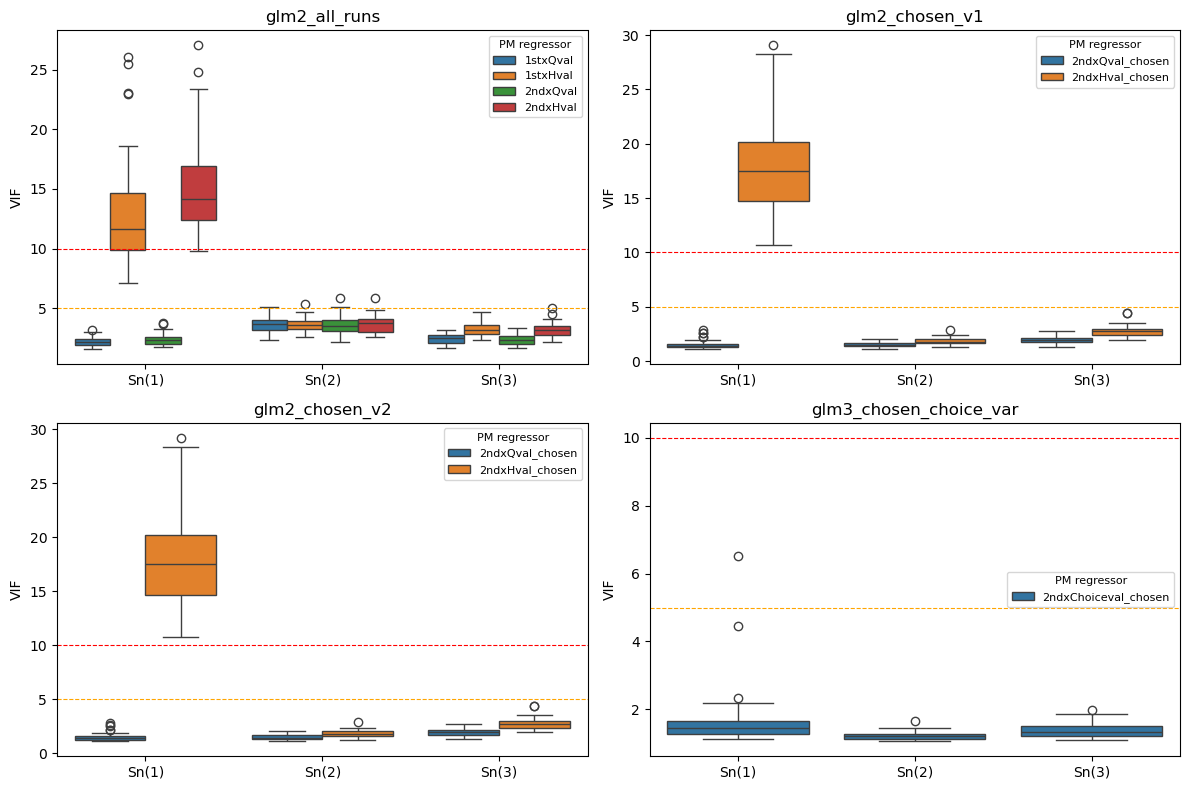

In [8]:
def shorten_pm(name):
    name = re.sub(r'\*bf\(\d+\)', '', name)
    name = re.sub(r'\^\d+', '', name)
    name = name.replace('first_stim', '1st').replace('second_stim', '2nd')
    return name

frames = []
for label, vifs in VIFs.items():
    pm_cols = [c for c in vifs.columns if 'x' in c]
    if not pm_cols:
        continue
    melted = vifs[pm_cols].reset_index().melt(
        id_vars=['subject', 'session'], var_name='regressor', value_name='VIF'
    )
    melted['regressor'] = melted['regressor'].map(shorten_pm)
    melted['model'] = label
    frames.append(melted)

if frames:
    df_all = pd.concat(frames, ignore_index=True)
    models = list(df_all['model'].unique())
    n_cols = 2
    n_rows = (len(models) + 1) // 2
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
    axes = axes.flat

    for ax, label in zip(axes, models):
        subset = df_all[df_all['model'] == label]
        sns.boxplot(data=subset, x='session', y='VIF', hue='regressor',
                    palette='tab10', ax=ax)
        ax.axhline(5,  color='orange', linestyle='--', linewidth=0.8)
        ax.axhline(10, color='red',    linestyle='--', linewidth=0.8)
        ax.set_title(label)
        ax.set_xlabel('')
        ax.legend(title='PM regressor', fontsize=8, title_fontsize=8)

    for ax in list(axes)[len(models):]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.show()

## VIF recomputation without Qval pmod

Drop the Qval parametric modulation columns from GLM2 and GLM2-chosen design matrices and recompute VIFs, to see how much the Hval pmod VIF is inflated by the presence of Qval.

In [9]:
QVAL_MODELS = ['glm2_all_runs', 'glm2_chosen_v1', 'glm2_chosen_v2']

VIFs_noQval = {}
for label in QVAL_MODELS:
    dms_noQval = {
        sub: dm[[c for c in dm.columns if 'Qval' not in c]]
        for sub, dm in DMs[label].items()
    }
    VIFs_noQval[label] = compute_vifs_allruns(dms_noQval)
    print(f'{label}: done')

glm2_all_runs: done


glm2_chosen_v1: done


glm2_chosen_v2: done


In [10]:
# Hval VIF describe(): with vs. without Qval, per model and session
for label in QVAL_MODELS:
    hval_orig = [c for c in VIFs[label].columns if 'Hval' in c]
    hval_new  = [c for c in VIFs_noQval[label].columns if 'Hval' in c]
    print(f'\n{"="*60}\n{label}\n{"="*60}')
    for col_orig, col_new in zip(hval_orig, hval_new):
        short = shorten_pm(col_orig)
        combined = pd.DataFrame({
            'with Qval':    VIFs[label][col_orig],
            'without Qval': VIFs_noQval[label][col_new],
        })
        print(f'\n  {short}')
        display(combined.groupby('session').describe().round(2))


glm2_all_runs

  1stxHval


with Qval                                               without Qval  \
            count   mean   std   min   25%    50%    75%    max        count   
session                                                                        
Sn(1)        51.0  12.99  4.36  7.09  9.89  11.63  14.63  26.01         51.0   
Sn(2)        34.0   3.60  0.60  2.56  3.27   3.58   3.92   5.34         34.0   
Sn(3)        40.0   3.26  0.51  2.36  2.83   3.19   3.61   4.71         40.0   

                                                      
          mean   std   min   25%   50%    75%    max  
session                                               
Sn(1)    10.17  3.52  5.60  7.97  9.04  11.77  22.30  
Sn(2)     1.71  0.33  1.33  1.52  1.62   1.75   3.09  
Sn(3)     1.60  0.21  1.28  1.46  1.53   1.73   2.05


  2ndxHval


with Qval                                                without Qval  \
            count   mean   std   min    25%    50%    75%    max        count   
session                                                                         
Sn(1)        51.0  14.98  3.66  9.78  12.42  14.12  16.93  27.01         51.0   
Sn(2)        34.0   3.68  0.73  2.62   3.02   3.73   4.11   5.87         34.0   
Sn(3)        40.0   3.22  0.55  2.17   2.78   3.19   3.47   5.00         40.0   

                                                       
          mean   std   min   25%    50%    75%    max  
session                                                
Sn(1)    11.44  3.32  6.41  9.36  10.73  12.88  22.79  
Sn(2)     1.74  0.26  1.36  1.55   1.68   1.86   2.46  
Sn(3)     1.62  0.18  1.32  1.50   1.57   1.73   2.05


glm2_chosen_v1

  2ndxHval_chosen


with Qval                                                  \
            count   mean   std    min    25%    50%    75%    max   
session                                                             
Sn(1)        51.0  18.04  4.44  10.72  14.70  17.47  20.16  29.05   
Sn(2)        34.0   1.86  0.31   1.29   1.63   1.79   2.04   2.83   
Sn(3)        40.0   2.73  0.57   1.97   2.36   2.74   2.98   4.41   

        without Qval                                                 
               count   mean   std   min    25%    50%    75%    max  
session                                                              
Sn(1)           51.0  15.46  3.87  9.50  13.14  14.68  17.06  27.02  
Sn(2)           34.0   1.47  0.21  1.18   1.34   1.40   1.57   1.97  
Sn(3)           40.0   1.87  0.28  1.45   1.70   1.82   2.03   2.98


glm2_chosen_v2

  2ndxHval_chosen


with Qval                                                  \
            count   mean   std    min    25%    50%    75%    max   
session                                                             
Sn(1)        51.0  18.05  4.46  10.73  14.70  17.53  20.21  29.17   
Sn(2)        34.0   1.86  0.32   1.29   1.63   1.79   2.04   2.88   
Sn(3)        40.0   2.73  0.57   1.97   2.36   2.75   2.98   4.41   

        without Qval                                                 
               count   mean   std   min    25%    50%    75%    max  
session                                                              
Sn(1)           51.0  15.48  3.89  9.51  13.15  14.65  17.11  27.13  
Sn(2)           34.0   1.47  0.21  1.18   1.34   1.41   1.57   1.99  
Sn(3)           40.0   1.87  0.28  1.45   1.71   1.82   2.03   2.99

In [ ]:
# Boxplot: Hval VIF with vs. without Qval — one panel per (model, Hval regressor)
frames_compare = []
for label in QVAL_MODELS:
    for variant, vifs_dict in [('with Qval', VIFs), ('without Qval', VIFs_noQval)]:
        hval_cols = [c for c in vifs_dict[label].columns if 'Hval' in c]
        melted = vifs_dict[label][hval_cols].reset_index().melt(
            id_vars=['subject', 'session'], var_name='regressor', value_name='VIF'
        )
        melted['regressor'] = melted['regressor'].map(shorten_pm)
        melted['model'] = label
        melted['variant'] = variant
        frames_compare.append(melted)

df_compare = pd.concat(frames_compare, ignore_index=True)

panels = df_compare[['model', 'regressor']].drop_duplicates().values.tolist()
fig, axes = plt.subplots(len(panels), 1, figsize=(10, 4 * len(panels)))
if len(panels) == 1:
    axes = [axes]

for ax, (label, reg) in zip(axes, panels):
    subset = df_compare[(df_compare['model'] == label) & (df_compare['regressor'] == reg)]
    sns.boxplot(data=subset, x='session', y='VIF', hue='variant',
                hue_order=['with Qval', 'without Qval'],
                palette=['steelblue', 'tomato'], ax=ax)
    ax.axhline(5,  color='orange', linestyle='--', linewidth=0.8)
    ax.axhline(10, color='red',    linestyle='--', linewidth=0.8)
    ax.set_title(f'{label} — {reg}: Hval VIF with vs. without Qval')
    ax.set_xlabel('Session')
    ax.legend(title='')

plt.tight_layout()
plt.show()

## Diagnosing the Sn(1) Hval VIF

Two diagnostics:
1. **Behavioral data** — distribution of raw Hval values per session. Low within-session variance → pmod regressor ≈ scaled copy of the main regressor → high VIF.
2. **Design matrix correlations** — direct correlation between `second_stim*bf(1)` and the Hval pmod regressor per session. This is the proximate cause of the VIF.

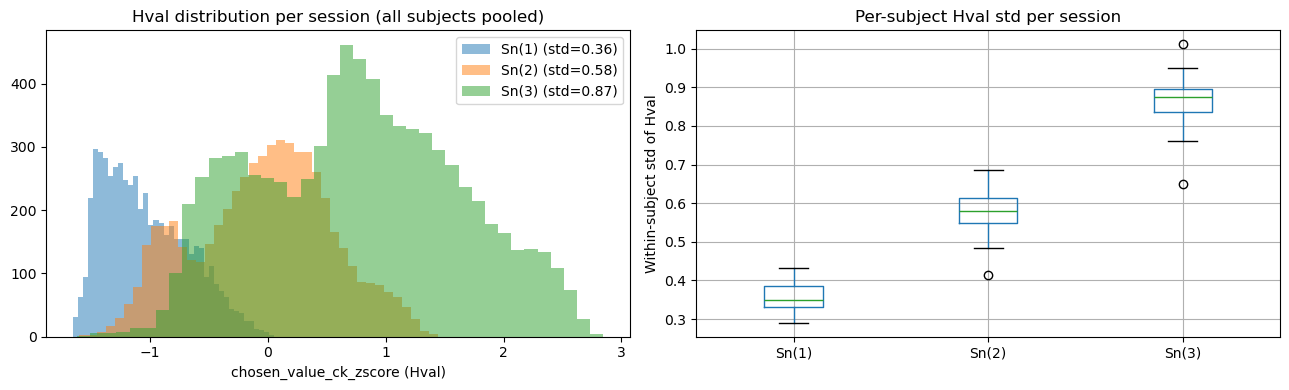


Hval within-session std — summary across subjects:


block,Sn(1),Sn(2),Sn(3)
count,60.000,60.000,60.000
mean,0.357,0.579,0.867
std,0.037,0.048,0.055
min,0.291,0.413,0.649
25%,0.331,0.549,0.836
50%,0.349,0.581,0.875
75%,0.386,0.615,0.897
max,0.433,0.687,1.011


In [12]:
BBT_PATH = '/home/ubuntu/data/learning-habits/bbt.csv'
bbt = pd.read_csv(BBT_PATH)
bbt_resp = bbt[bbt['action'].notna()].copy()

block_to_sn = {'learning1': 'Sn(1)', 'learning2': 'Sn(2)', 'test': 'Sn(3)'}
bbt_resp['session'] = bbt_resp['block'].map(block_to_sn)

# Per-subject within-session std
hval_std = (
    bbt_resp.groupby(['sub_id', 'block'])['chosen_value_ck_zscore']
    .std()
    .unstack('block')
    .rename(columns=block_to_sn)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: histogram per session (pooled across subjects)
ax = axes[0]
for block, sn in block_to_sn.items():
    vals = bbt_resp.loc[bbt_resp['block'] == block, 'chosen_value_ck_zscore'].dropna()
    ax.hist(vals, bins=40, alpha=0.5, label=f'{sn} (std={vals.std():.2f})')
ax.set_xlabel('chosen_value_ck_zscore (Hval)')
ax.set_title('Hval distribution per session (all subjects pooled)')
ax.legend()

# Right: boxplot of per-subject within-session std
ax = axes[1]
hval_std.boxplot(ax=ax)
ax.set_ylabel('Within-subject std of Hval')
ax.set_title('Per-subject Hval std per session')

plt.tight_layout()
plt.show()

print('\nHval within-session std — summary across subjects:')
display(hval_std.describe().round(3))

In [ ]:
HVAL_MODELS = {
    'glm2_all_runs':  'Hval^1',
    'glm2_chosen_v1': 'Hval_chosen',
    'glm2_chosen_v2': 'Hval_chosen',
}


def compute_pmod_main_corr(DMs, hval_substr, n_sessions=3):
    """
    For each Hval pmod column, correlate with its matching main condition regressor.
    Condition is matched by the prefix before 'x' in the pmod column name.
    """
    records = []
    for sub, dm in DMs.items():
        for sn in range(1, n_sessions + 1):
            prefix = f'Sn({sn}) '
            hval_cols = [c for c in dm.columns if c.startswith(prefix) and hval_substr in c]
            for hc in hval_cols:
                cond = hc[len(prefix):].split('x')[0]   # e.g. 'first_stim' or 'second_stim'
                main_col = f'{prefix}{cond}*bf(1)'
                if main_col not in dm.columns:
                    continue
                corr = dm[main_col].corr(dm[hc])
                records.append({
                    'subject': sub,
                    'session': f'Sn({sn})',
                    'condition': shorten_pm(cond),
                    'r': corr,
                })
    return pd.DataFrame(records)


all_main_corrs = {}
for label, hval_substr in HVAL_MODELS.items():
    all_main_corrs[label] = compute_pmod_main_corr(DMs[label], hval_substr)

# Summary table
print('=== r(main regressor, Hval pmod) — mean (std) across subjects ===\n')
for label, df in all_main_corrs.items():
    print(f'--- {label} ---')
    display(df.groupby(['condition', 'session'])['r'].agg(['mean', 'std']).round(3))
    print()

# Boxplot: one panel per (model, condition)
panels = [
    (label, cond)
    for label, df in all_main_corrs.items()
    for cond in sorted(df['condition'].unique())
]
fig, axes = plt.subplots(1, len(panels), figsize=(5 * len(panels), 4), sharey=True)
if len(panels) == 1:
    axes = [axes]

for ax, (label, cond) in zip(axes, panels):
    subset = all_main_corrs[label][all_main_corrs[label]['condition'] == cond]
    sns.boxplot(data=subset, x='session', y='r', color='steelblue', ax=ax)
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    ax.set_title(f'{label}\n{cond}')
    ax.set_xlabel('')
    ax.set_ylabel('r(main, Hval pmod)')

plt.suptitle('Correlation: main condition regressor vs Hval pmod', y=1.02)
plt.tight_layout()
plt.show()

## Qval–Hval pmod correlations

For models with both Q and H parametric modulators: correlation between the two pmod regressors in the design matrix, per session and overall (mean across sessions).

In [20]:
QH_MODELS = {
    'glm2_all_runs':  {'Qval': 'Qval^1', 'Hval': 'Hval^1'},
    'glm2_chosen_v1': {'Qval': 'Qval_chosen', 'Hval': 'Hval_chosen'},
    'glm2_chosen_v2': {'Qval': 'Qval_chosen', 'Hval': 'Hval_chosen'},
}


def compute_qh_pmod_corr(DMs, qval_substr, hval_substr, n_sessions=3):
    """
    For each subject and session, correlate every Qval pmod column with its
    matching Hval pmod column (matched by condition prefix before the 'x').
    """
    records = []
    for sub, dm in DMs.items():
        for sn in range(1, n_sessions + 1):
            prefix = f'Sn({sn}) '
            q_cols = [c for c in dm.columns if c.startswith(prefix) and qval_substr in c]
            h_cols = [c for c in dm.columns if c.startswith(prefix) and hval_substr in c]

            for qc in q_cols:
                cond = qc[len(prefix):].split('x')[0]   # e.g. 'first_stim' or 'second_stim'
                hc = next((c for c in h_cols if c[len(prefix):].startswith(cond)), None)
                if hc is None:
                    continue
                corr = dm[qc].corr(dm[hc])
                records.append({
                    'subject': sub,
                    'session': f'Sn({sn})',
                    'condition': cond.rstrip('*'),
                    'r': corr,
                })
    return pd.DataFrame(records)


all_corrs = {}
for label, substrs in QH_MODELS.items():
    all_corrs[label] = compute_qh_pmod_corr(
        DMs[label], substrs['Qval'], substrs['Hval']
    )

# Summary table: mean r per session + overall mean
print('=== r(Qval pmod, Hval pmod) — mean (std) across subjects ===\n')
for label, df in all_corrs.items():
    print(f'--- {label} ---')
    per_sess = df.groupby(['condition', 'session'])['r'].agg(['mean', 'std']).round(3)
    overall  = df.groupby('condition')['r'].agg(['mean', 'std']).round(3)
    overall.index = pd.MultiIndex.from_tuples(
        [(c, 'overall') for c in overall.index], names=['condition', 'session']
    )
    display(pd.concat([per_sess, overall]).sort_index())
    print()

=== r(Qval pmod, Hval pmod) — mean (std) across subjects ===

--- glm2_all_runs ---


mean    std
condition   session              
first_stim  Sn(1)    0.208  0.100
            Sn(2)    0.526  0.109
            Sn(3)    0.622  0.053
            overall  0.452  0.199
second_stim Sn(1)    0.270  0.103
            Sn(2)    0.585  0.100
            Sn(3)    0.592  0.068
            overall  0.483  0.176


--- glm2_chosen_v1 ---


mean    std
condition   session              
second_stim Sn(1)    0.304  0.128
            Sn(2)    0.401  0.131
            Sn(3)    0.473  0.083
            overall  0.393  0.135


--- glm2_chosen_v2 ---


mean    std
condition   session              
second_stim Sn(1)    0.304  0.128
            Sn(2)    0.401  0.131
            Sn(3)    0.473  0.083
            overall  0.393  0.135

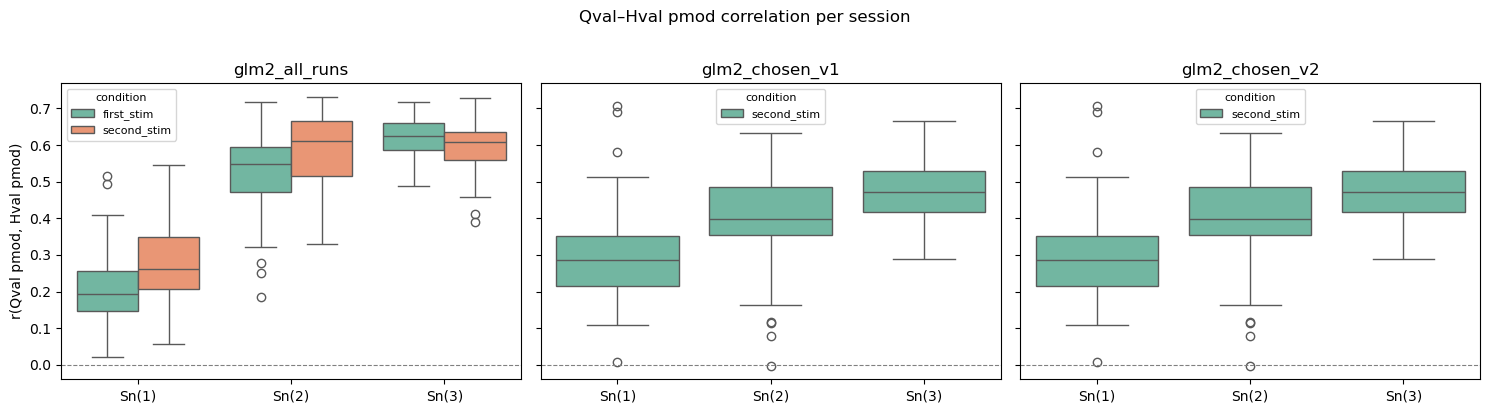

In [21]:
# Boxplot: r(Qval, Hval) per session, one panel per model
n = len(QH_MODELS)
fig, axes = plt.subplots(1, n, figsize=(5 * n, 4), sharey=True)

for ax, (label, df) in zip(axes, all_corrs.items()):
    sns.boxplot(data=df, x='session', y='r', hue='condition',
                palette='Set2', ax=ax)
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    ax.set_title(label)
    ax.set_xlabel('')
    ax.set_ylabel('r(Qval pmod, Hval pmod)')
    ax.legend(title='condition', fontsize=8, title_fontsize=8)

plt.suptitle('Qval–Hval pmod correlation per session', y=1.02)
plt.tight_layout()
plt.show()

# Compare with old VIFs
How did the normalization affect the VIFs for H-values?

the old notebook has reasonnable VIFs for secondstimxHval, glm2_2025-09-15-06-08.

It zscore for each run separately.

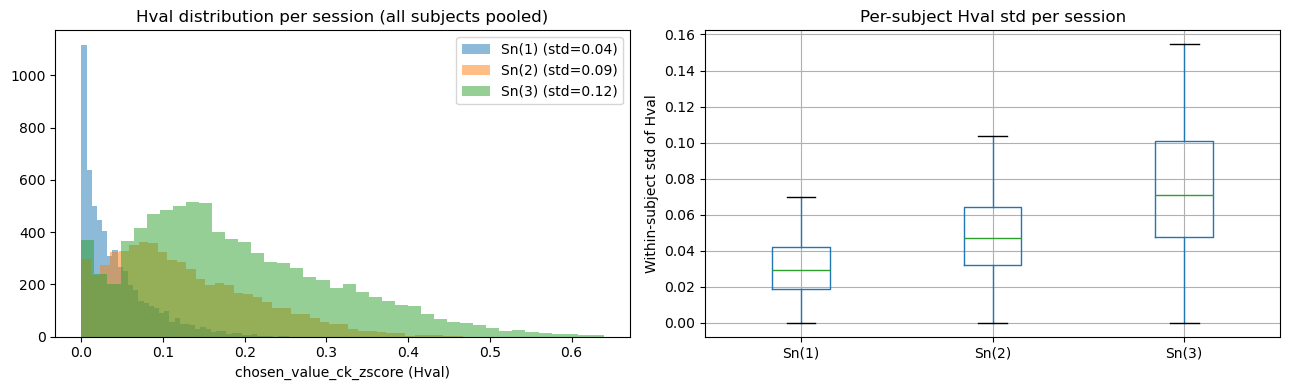


Hval within-session std — summary across subjects:


block,Sn(1),Sn(2),Sn(3)
count,62.000,62.000,62.000
mean,0.031,0.049,0.073
std,0.017,0.026,0.038
min,0.000,0.000,0.000
25%,0.019,0.032,0.047
50%,0.029,0.047,0.071
75%,0.042,0.064,0.101
max,0.070,0.104,0.155


In [7]:
bbt_resp = bbt[bbt['action'].notna()].copy()

block_to_sn = {'learning1': 'Sn(1)', 'learning2': 'Sn(2)', 'test': 'Sn(3)'}
bbt_resp['session'] = bbt_resp['block'].map(block_to_sn)

# Per-subject within-session std
hval_std = (
    bbt_resp.groupby(['sub_id', 'block'])['chosen_value_ck']
    .std()
    .unstack('block')
    .rename(columns=block_to_sn)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: histogram per session (pooled across subjects)
ax = axes[0]
for block, sn in block_to_sn.items():
    vals = bbt_resp.loc[bbt_resp['block'] == block, 'chosen_value_ck'].dropna()
    ax.hist(vals, bins=40, alpha=0.5, label=f'{sn} (std={vals.std():.2f})')
ax.set_xlabel('chosen_value_ck_zscore (Hval)')
ax.set_title('Hval distribution per session (all subjects pooled)')
ax.legend()

# Right: boxplot of per-subject within-session std
ax = axes[1]
hval_std.boxplot(ax=ax)
ax.set_ylabel('Within-subject std of Hval')
ax.set_title('Per-subject Hval std per session')

plt.tight_layout()
plt.show()

print('\nHval within-session std — summary across subjects:')
display(hval_std.describe().round(3))

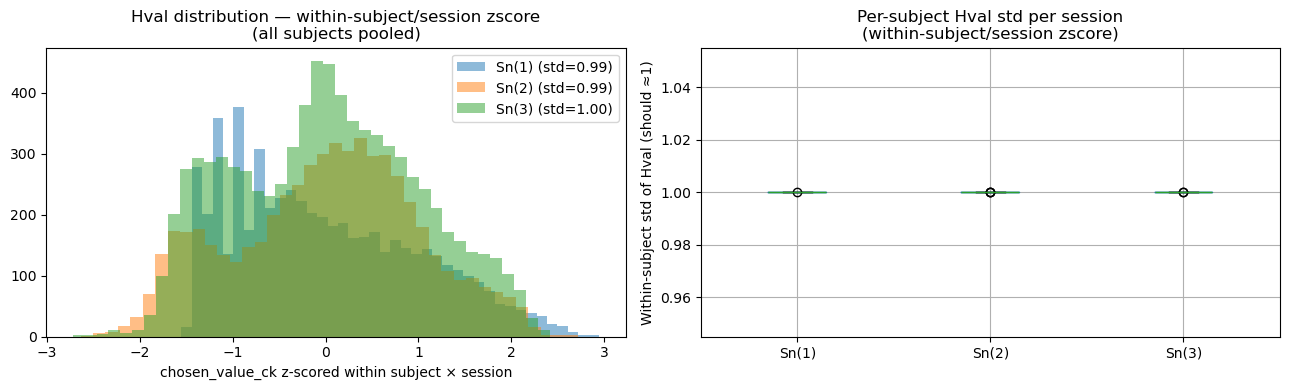


Hval within-session std — summary across subjects (within-subject/session zscore):


block,Sn(1),Sn(2),Sn(3)
count,60.0,60.0,60.0
mean,1.0,1.0,1.0
std,0.0,0.0,0.0
min,1.0,1.0,1.0
25%,1.0,1.0,1.0
50%,1.0,1.0,1.0
75%,1.0,1.0,1.0
max,1.0,1.0,1.0


In [8]:

# Z-score chosen_value_ck within each subject × session (block)
bbt_resp['chosen_value_ck_zscore_within'] = (
    bbt_resp.groupby(['sub_id', 'block'])['chosen_value_ck']
    .transform(lambda x: (x - x.mean()) / x.std())
)

hval_std_within = (
    bbt_resp.groupby(['sub_id', 'block'])['chosen_value_ck_zscore_within']
    .std()
    .unstack('block')
    .rename(columns=block_to_sn)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
for block, sn in block_to_sn.items():
    vals = bbt_resp.loc[bbt_resp['block'] == block, 'chosen_value_ck_zscore_within'].dropna()
    ax.hist(vals, bins=40, alpha=0.5, label=f'{sn} (std={vals.std():.2f})')
ax.set_xlabel('chosen_value_ck z-scored within subject × session')
ax.set_title('Hval distribution — within-subject/session zscore\n(all subjects pooled)')
ax.legend()

ax = axes[1]
hval_std_within.boxplot(ax=ax)
ax.set_ylabel('Within-subject std of Hval (should ≈1)')
ax.set_title('Per-subject Hval std per session\n(within-subject/session zscore)')

plt.tight_layout()
plt.show()

print('\nHval within-session std — summary across subjects (within-subject/session zscore):')
display(hval_std_within.describe().round(3))


## Demeaned models: glm2_all_runs_demean and glm2_chosen_all_runs_demean

VIFs for the two new models using subject-level demeaning (mean subtracted across all runs per subject) instead of z-scoring per run.

In [8]:
DEMEAN_MODELS = {
    'glm2_all_runs_demean':        'glm2_all_runs_scrubbed_demeaned_2026-05-11-08-26',
    'glm2_chosen_all_runs_demean': 'glm2_chosen_all_runs_scrubbed_demeaned_2026-05-11-08-21',
}

DMs_demean = {}
VIFs_demean = {}

for label, dirname in DEMEAN_MODELS.items():
    model_dir = os.path.join(OUTPUTS_DIR, dirname)
    print(f'Loading {label} ...', end=' ')
    dms = load_dms_allruns(model_dir)
    DMs_demean[label] = dms
    print(f'{len(dms)} subjects')
    vifs = compute_vifs_allruns(dms)
    VIFs_demean[label] = vifs
    print(f'  → VIFs: {vifs.shape[0]} rows, {vifs.shape[1]} regressors')

for label, vifs in VIFs_demean.items():
    print(f'\n=== {label} ===')
    display(vifs.describe().round(2))

Loading glm2_all_runs_demean ... 60 subjects
  → VIFs: 125 rows, 10 regressors
Loading glm2_chosen_all_runs_demean ... 60 subjects
  → VIFs: 125 rows, 9 regressors

=== glm2_all_runs_demean ===


,first_stim*bf(1),first_stimxQval^1*bf(1),first_stimxHval^1*bf(1),second_stim*bf(1),second_stimxQval^1*bf(1),second_stimxHval^1*bf(1),response*bf(1),purple_frame*bf(1),points_feedback*bf(1),nresp_screen*bf(1)
count,125.00,125.00,125.00,125.00,125.00,125.00,125.00,125.00,85.00,125.00
mean,39.46,2.67,7.33,27.51,2.72,8.14,925.09,1112.94,72.07,3.30
std,21.51,0.75,5.50,9.86,0.77,6.17,681.58,785.75,8.78,9.84
min,8.27,1.61,2.36,12.38,1.65,2.18,11.64,14.30,51.60,1.43
25%,11.24,2.07,3.25,18.97,2.16,3.22,17.98,71.83,65.64,1.87
50%,45.65,2.51,3.97,25.99,2.49,4.09,1176.18,1419.32,71.00,2.26
75%,55.94,3.01,10.87,35.41,3.12,13.31,1413.82,1655.30,76.52,2.93
max,84.90,5.15,26.05,52.11,5.87,27.04,2939.23,3391.58,105.22,112.14



=== glm2_chosen_all_runs_demean ===


,first_stim*bf(1),second_stim*bf(1),second_stimxQval_chosen^1*bf(1),second_stimxHval_chosen^1*bf(1),response*bf(1),purple_frame*bf(1),points_feedback*bf(1),nresp_screen*bf(1),second_stim_nresp*bf(1)
count,125.00,125.00,125.00,125.00,125.00,125.00,85.00,125.00,125.00
mean,47.43,30.43,1.65,8.75,1153.88,1241.41,71.97,10.35,11.66
std,26.79,11.75,0.39,8.27,865.76,902.64,8.70,22.27,4.73
min,8.21,11.53,1.14,1.29,13.55,13.82,51.51,5.78,6.00
25%,10.82,20.43,1.36,2.11,21.17,71.44,65.92,7.08,8.44
50%,59.97,28.71,1.55,2.88,1445.22,1541.51,71.02,7.90,10.25
75%,66.51,37.79,1.89,15.96,1706.56,1834.32,75.91,9.23,13.91
max,92.11,68.24,2.83,29.17,4372.17,4525.72,104.82,256.53,38.26


In [9]:
# PM VIF max per session
for label, vifs in VIFs_demean.items():
    pm_cols = [c for c in vifs.columns if 'x' in c]
    print(f'\n=== {label} ===')
    display(vifs[pm_cols].groupby('session').max().round(1))


=== glm2_all_runs_demean ===


,first_stimxQval^1*bf(1),first_stimxHval^1*bf(1),second_stimxQval^1*bf(1),second_stimxHval^1*bf(1)
session,,,,
Sn(1),3.2,26.0,3.8,27.0
Sn(2),5.1,5.3,5.9,5.9
Sn(3),3.2,4.7,3.3,5.0



=== glm2_chosen_all_runs_demean ===


,second_stimxQval_chosen^1*bf(1),second_stimxHval_chosen^1*bf(1)
session,,
Sn(1),2.8,29.2
Sn(2),2.1,2.9
Sn(3),2.7,4.4


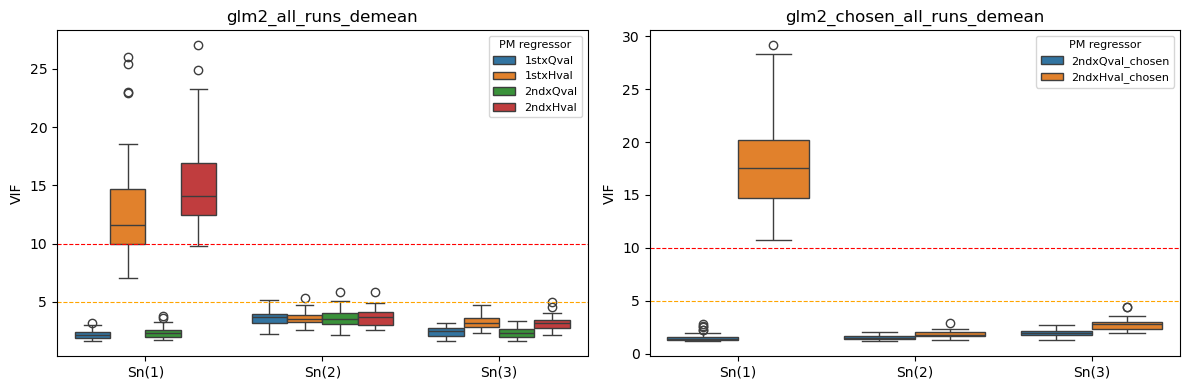

In [ ]:
frames = []
for label, vifs in VIFs_demean.items():
    pm_cols = [c for c in vifs.columns if 'x' in c]
    if not pm_cols:
        continue
    melted = vifs[pm_cols].reset_index().melt(
        id_vars=['subject', 'session'], var_name='regressor', value_name='VIF'
    )
    melted['regressor'] = melted['regressor'].map(shorten_pm)
    melted['model'] = label
    frames.append(melted)

if frames:
    df_demean = pd.concat(frames, ignore_index=True)
    models = list(df_demean['model'].unique())
    n_cols = 2
    n_rows = (len(models) + 1) // 2
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
    axes = axes.flat

    for ax, label in zip(axes, models):
        subset = df_demean[df_demean['model'] == label]
        sns.boxplot(data=subset, x='session', y='VIF', hue='regressor',
                    palette='tab10', ax=ax)
        ax.axhline(5,  color='orange', linestyle='--', linewidth=0.8)
        ax.axhline(10, color='red',    linestyle='--', linewidth=0.8)
        ax.set_title(label)
        ax.set_xlabel('')
        ax.legend(title='PM regressor', fontsize=8, title_fontsize=8)

    for ax in list(axes)[len(models):]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.show()

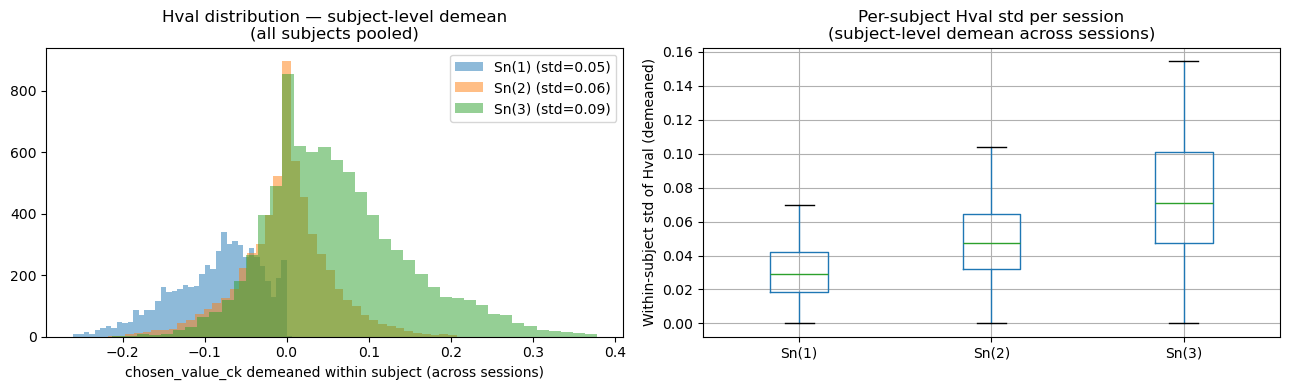


Hval within-session std — summary across subjects (subject-level demean):


block,Sn(1),Sn(2),Sn(3)
count,62.000,62.000,62.000
mean,0.031,0.049,0.073
std,0.017,0.026,0.038
min,0.000,0.000,0.000
25%,0.019,0.032,0.047
50%,0.029,0.047,0.071
75%,0.042,0.064,0.101
max,0.070,0.104,0.155


In [13]:
bbt_resp = bbt[bbt['action'].notna()].copy()

block_to_sn = {'learning1': 'Sn(1)', 'learning2': 'Sn(2)', 'test': 'Sn(3)'}
bbt_resp['session'] = bbt_resp['block'].map(block_to_sn)

# Demean chosen_value_ck within subject, across all sessions
bbt_resp['chosen_value_ck_demeaned'] = (
    bbt_resp.groupby('sub_id')['chosen_value_ck']
    .transform(lambda x: x - x.mean())
)

# Per-subject within-session std of demeaned values
hval_std_demean = (
    bbt_resp.groupby(['sub_id', 'block'])['chosen_value_ck_demeaned']
    .std()
    .unstack('block')
    .rename(columns=block_to_sn)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
for block, sn in block_to_sn.items():
    vals = bbt_resp.loc[bbt_resp['block'] == block, 'chosen_value_ck_demeaned'].dropna()
    ax.hist(vals, bins=40, alpha=0.5, label=f'{sn} (std={vals.std():.2f})')
ax.set_xlabel('chosen_value_ck demeaned within subject (across sessions)')
ax.set_title('Hval distribution — subject-level demean\n(all subjects pooled)')
ax.legend()

ax = axes[1]
hval_std_demean.boxplot(ax=ax)
ax.set_ylabel('Within-subject std of Hval (demeaned)')
ax.set_title('Per-subject Hval std per session\n(subject-level demean across sessions)')

plt.tight_layout()
plt.show()

print('\nHval within-session std — summary across subjects (subject-level demean):')
display(hval_std_demean.describe().round(3))


In [16]:
VIFs_demean['glm2_all_runs_demean'].head()

first_stim*bf(1)  first_stimxQval^1*bf(1)  \
subject session                                              
sub-01  Sn(1)           63.857491                 2.933486   
        Sn(2)           53.015384                 3.545949   
        Sn(3)           10.289299                 2.923631   
sub-03  Sn(1)           46.237594                 1.984768   
        Sn(2)           42.458457                 3.195826   

                 first_stimxHval^1*bf(1)  second_stim*bf(1)  \
subject session                                               
sub-01  Sn(1)                  18.203759          39.893618   
        Sn(2)                   3.445304          19.608484   
        Sn(3)                   3.982626          14.622753   
sub-03  Sn(1)                  14.524666          33.555140   
        Sn(2)                   3.392699          23.515207   

                 second_stimxQval^1*bf(1)  second_stimxHval^1*bf(1)  \
subject session                                                       
sub-01  Sn(1)                    3.106170                 18.244352   
        Sn(2)                    3.989303                  3.930384   
        Sn(3)                    2.742354                  3.739000   
sub-03  Sn(1)                    2.337668                 12.485326   
        Sn(2)                    3.602885                  3.606639   

                 response*bf(1)  purple_frame*bf(1)  points_feedback*bf(1)  \
subject session                                                              
sub-01  Sn(1)       2939.233219         3391.575185              74.289031   
        Sn(2)       2858.308989         3109.628045              66.641100   
        Sn(3)         14.565198           19.329324                    NaN   
sub-03  Sn(1)       1176.177452         1513.903016              72.208973   
        Sn(2)       1255.723669         1586.543472              73.713110   

                 nresp_screen*bf(1)  
subject session                      
sub-01  Sn(1)              2.577456  
        Sn(2)              2.523246  
        Sn(3)              1.451860  
sub-03  Sn(1)              3.194899  
        Sn(2)              3.338309

In [17]:
VIFs['glm2_all_runs'].head()


NameError: name 'VIFs' is not defined